Detached kernel driver
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
Exact sample rate is: 2000000.052982 Hz


[*] RTL-SDR Configurado a 917.0 MHz (Offset). Esperando señal en 917.5 MHz...


Allocating 15 zero-copy buffers


[*] Grabando 10.0 segundos...


Reattached kernel driver


[+] Captura finalizada. Total de muestras: 19988480
[*] Calculando espectro Max Hold...


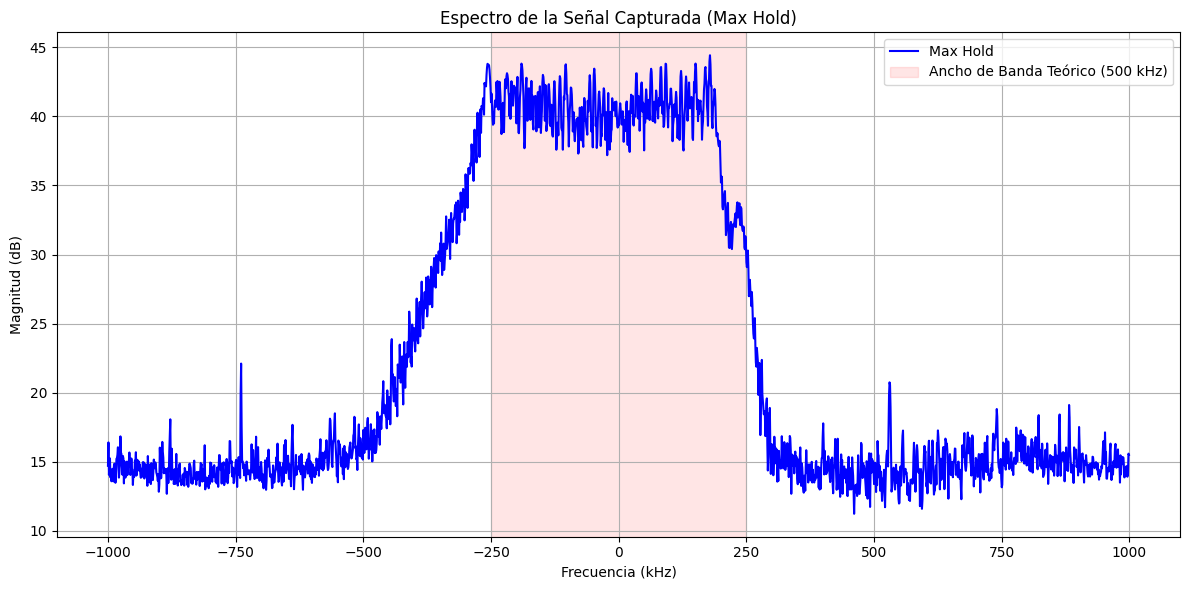

[+] Parámetros LoRa: SF=8, BW=500kHz, N=256, Os=4, N_sym=1024


In [151]:
import sys
import os
sys.path.append(os.path.abspath('../../'))

import numpy as np
import matplotlib.pyplot as plt
import time
from hardware.rtlsdr_handler import RtlSdrHandler

# ============================================================
# 1. CAPTURA Y GRÁFICO DE ESPECTRO (MAX HOLD)
# ============================================================
sample_rate = 2e6
target_freq = 917.5e6
offset_freq = 0.5e6
center_freq = target_freq - offset_freq

captured_samples = []
def rx_callback(samples):
    captured_samples.append(samples.copy())

sdr = RtlSdrHandler(rx_callback)
sdr.configurar(sample_rate, center_freq)
sdr.set_gain('auto')

print(f"[*] RTL-SDR Configurado a {center_freq/1e6} MHz (Offset). Esperando señal en {target_freq/1e6} MHz...")
sdr.start_rx()
time.sleep(2.0)
captured_samples.clear()

duration = 10.0
print(f"[*] Grabando {duration} segundos...")
time.sleep(duration)
sdr.stop_rx()
sdr.close()

iq_raw = np.concatenate(captured_samples)
print(f"[+] Captura finalizada. Total de muestras: {len(iq_raw)}")

# Offset Tuning: movemos la señal a banda base
t_raw = np.arange(len(iq_raw)) / sample_rate
iq_base = iq_raw * np.exp(-1j * 2 * np.pi * offset_freq * t_raw)

# Calculamos el espectro con retención de máximos (Max Hold)
nfft = 2048
print("[*] Calculando espectro Max Hold...")
num_blocks = len(iq_base) // nfft
max_hold = np.zeros(nfft)

for i in range(num_blocks):
    block = iq_base[i*nfft : (i+1)*nfft]
    # Aplicamos ventana Blackman para reducir fuga espectral
    windowed = block * np.blackman(nfft)
    # FFT y shift
    S = np.fft.fftshift(np.fft.fft(windowed))
    mag = 20 * np.log10(np.abs(S) + 1e-12)
    max_hold = np.maximum(max_hold, mag)

freqs = np.fft.fftshift(np.fft.fftfreq(nfft, d=1/sample_rate)) / 1e3 # en kHz

plt.figure(figsize=(12, 6))
plt.plot(freqs, max_hold, color='blue', label='Max Hold')
plt.axvspan(-250, 250, color='red', alpha=0.1, label='Ancho de Banda Teórico (500 kHz)')
plt.title('Espectro de la Señal Capturada (Max Hold)')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Magnitud (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PARÁMETROS LoRa Y CHIRPS DE REFERENCIA
# ============================================================
BW = 500e3
SF = 8
N = 2**SF                          # 256 chips por símbolo
Os = int(sample_rate / BW)         # Factor de sobremuestreo: 4
N_sym = N * Os                     # 1024 muestras por símbolo
T_sym = N / BW                     # Duración del símbolo en segundos

# Chirp base (up-chirp no modulado, s=0)
# Frecuencia instantánea: f(t) = -BW/2 + (BW/T_sym)*t
# Fase: φ(t) = 2π * ∫f(τ)dτ = 2π * (-BW/2 * t + BW/(2*T_sym) * t²)
t_chirp = np.arange(N_sym) / sample_rate
phase_up = 2 * np.pi * (-BW/2 * t_chirp + BW/(2*T_sym) * t_chirp**2)
base_up_chirp = np.exp(1j * phase_up)
base_down = np.conj(base_up_chirp)

print(f"[+] Parámetros LoRa: SF={SF}, BW={BW/1e3:.0f}kHz, N={N}, Os={Os}, N_sym={N_sym}")


[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...
[*] Procesando 78076 ventanas (Stride=256 muestras)...
[+] ¡Preámbulo detectado! Inicio aproximado en la muestra 7334144
[+] Bin CFO detectado (k_coarse): 887
[+] PAPR de la primera ventana: 263.11


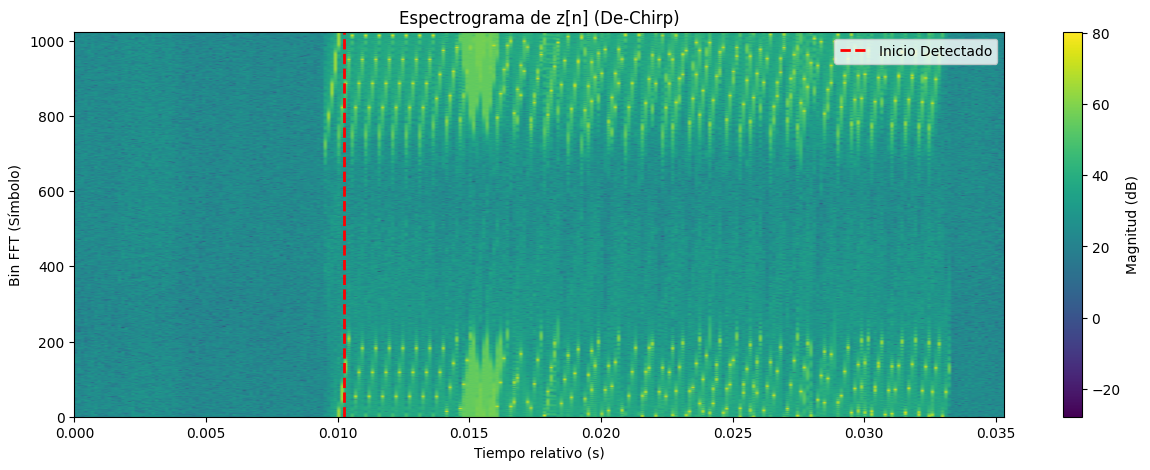

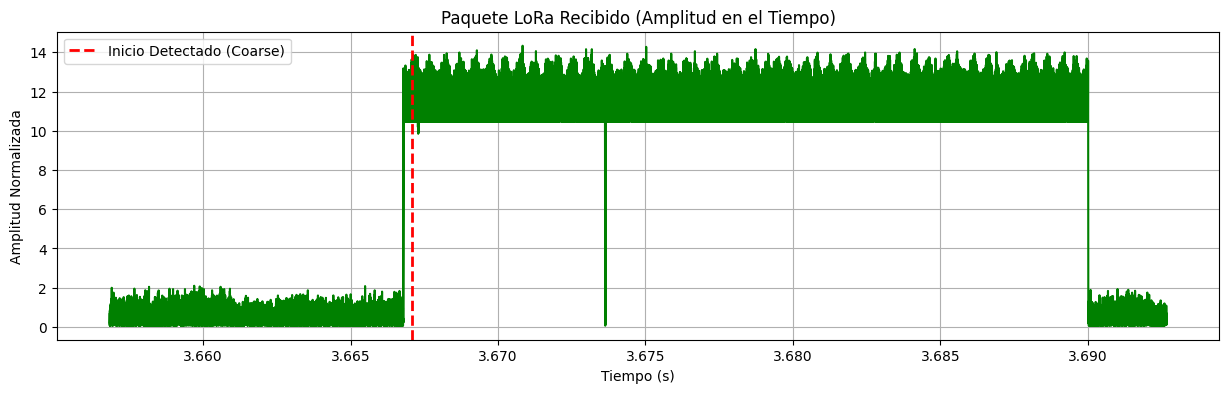

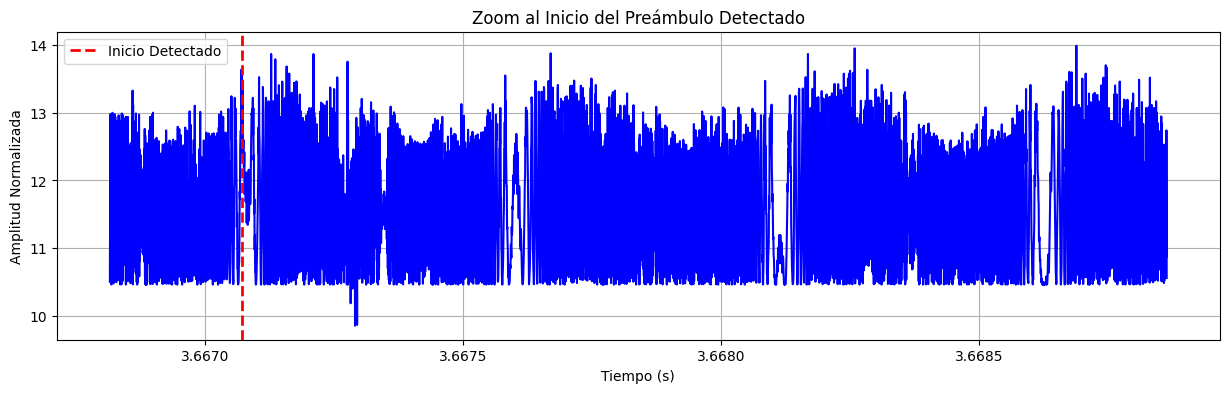

In [152]:
# ============================================================
# 2. ETAPA 1: DETECCIÓN GRUESA DEL PREÁMBULO (Sliding Window)
# ============================================================

print("[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...")

# 1. Normalización de Ganancia
iq_norm = iq_base / np.std(iq_base)

# Parámetros del algoritmo de ventana deslizante
N_samples = N_sym
h = N_samples // 4  # Zancada de N_samples / 4
PAPR_THRESHOLD = 10.0
M = 4 # Número de símbolos consecutivos requeridos

num_windows = (len(iq_norm) - N_samples) // h
papr_history = np.zeros(num_windows)
bin_history = np.zeros(num_windows, dtype=int)

print(f"[*] Procesando {num_windows} ventanas (Stride={h} muestras)...")
for i in range(num_windows):
    start_idx = i * h
    window_iq = iq_norm[start_idx : start_idx + N_samples]
    
    # De-chirping
    z = window_iq * base_down
    
    # FFT
    Z = np.fft.fft(z)
    Z_mag_sq = np.abs(Z)**2
    
    # Métrica de Detección (PAPR)
    max_Z_sq = np.max(Z_mag_sq)
    avg_Z_sq = np.mean(Z_mag_sq)
    papr = max_Z_sq / avg_Z_sq
    
    papr_history[i] = papr
    bin_history[i] = np.argmax(Z_mag_sq)

# Búsqueda de M símbolos consecutivos en la misma alineación
# Como el salto es N_samples/4, un símbolo entero son 4 ventanas.
stride_per_sym = N_samples // h
detected_window = -1

for i in range(num_windows - M * stride_per_sym):
    if papr_history[i] < PAPR_THRESHOLD:
        continue
        
    target_bin = bin_history[i]
    valid = True
    for m in range(1, M):
        idx = i + m * stride_per_sym
        # Tolerancia de +-1 bin por ruido/CFO fraccional
        bin_diff = abs(bin_history[idx] - target_bin)
        bin_diff = min(bin_diff, N_samples - bin_diff)
        
        if papr_history[idx] < PAPR_THRESHOLD or bin_diff > 2:
            valid = False
            break
            
    if valid:
        detected_window = i
        break

if detected_window != -1:
    coarse_start_idx = detected_window * h
    print(f"[+] ¡Preámbulo detectado! Inicio aproximado en la muestra {coarse_start_idx}")
    print(f"[+] Bin CFO detectado (k_coarse): {bin_history[detected_window]}")
    print(f"[+] PAPR de la primera ventana: {papr_history[detected_window]:.2f}")
else:
    print("[-] No se detectó ningún preámbulo.")
    coarse_start_idx = 0

# ============================================================
# GRÁFICOS
# ============================================================
if detected_window != -1:
    # 0. Espectrograma del De-Chirp (FFT de z) alrededor del paquete
    # Calculamos el espectrograma de la señal de-chirped solo en la región del paquete
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    spec_windows = (end_plot - start_plot - N_samples) // h
    spectrogram = np.zeros((N_samples, spec_windows))
    
    for w in range(spec_windows):
        idx = start_plot + w * h
        chunk = iq_norm[idx : idx + N_samples]
        z_chunk = chunk * base_down
        Z_mag = 20 * np.log10(np.abs(np.fft.fft(z_chunk)) + 1e-12)
        spectrogram[:, w] = Z_mag
        
    plt.figure(figsize=(15, 5))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis', 
               extent=[0, spec_windows * h / sample_rate, 0, N_samples])
    plt.axvline((coarse_start_idx - start_plot) / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Espectrograma de z[n] (De-Chirp)')
    plt.xlabel('Tiempo relativo (s)')
    plt.ylabel('Bin FFT (Símbolo)')
    plt.colorbar(label='Magnitud (dB)')
    plt.legend()
    plt.show()
    
    # 1. Gráfico en el tiempo del paquete completo recibido
    # Asumimos una longitud de paquete segura de 30 símbolos
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    t_paquete = np.arange(start_plot, end_plot) / sample_rate
    paquete_iq = iq_norm[start_plot:end_plot]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_paquete, np.abs(paquete_iq), color='green')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Coarse)')
    plt.title('Paquete LoRa Recibido (Amplitud en el Tiempo)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 2. Gráfico con Zoom al inicio detectado (4 símbolos)
    zoom_start = max(0, coarse_start_idx - int(0.5 * N_samples))
    zoom_end = min(len(iq_norm), coarse_start_idx + int(3.5 * N_samples))
    
    t_zoom = np.arange(zoom_start, zoom_end) / sample_rate
    zoom_iq = iq_norm[zoom_start:zoom_end]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_zoom, np.abs(zoom_iq), color='blue')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Zoom al Inicio del Preámbulo Detectado')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()


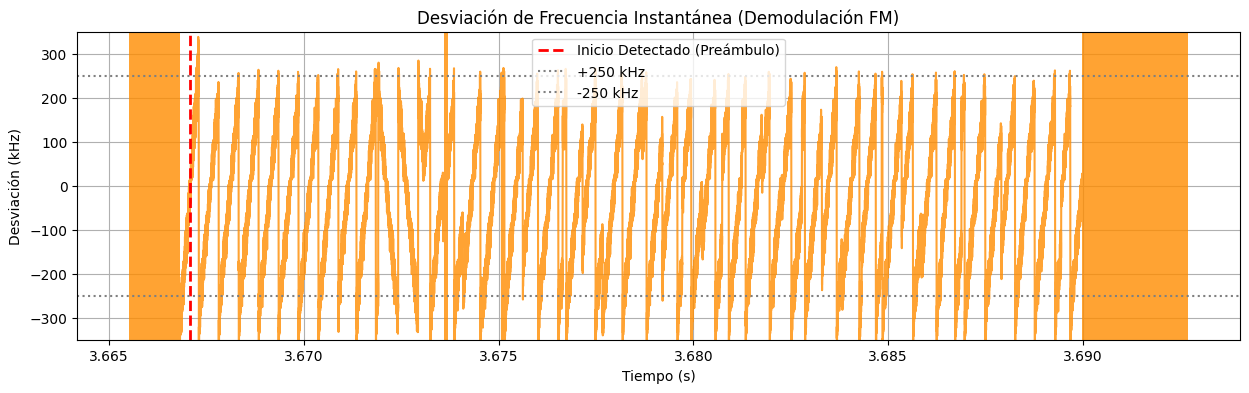

In [153]:
# ============================================================
# 3. DEMODULACIÓN FM (FRECUENCIA INSTANTÁNEA)
# ============================================================

if detected_window != -1:
    start_fm = max(0, coarse_start_idx - 3 * N_samples)
    burst_len = int(50 * N_samples)
    end_fm = min(len(iq_norm), coarse_start_idx + burst_len)
    
    iq_fm = iq_norm[start_fm:end_fm]
    t_fm = np.arange(start_fm, end_fm - 1) / sample_rate
    
    # Demodulación FM vectorizada (Derivada de la fase matemática)
    # f_inst[n] = Fs / (2*pi) * arg( x[n] * conj(x[n-1]) )
    f_inst = np.angle(iq_fm[1:] * np.conjugate(iq_fm[:-1])) * (sample_rate / (2 * np.pi))
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_fm, f_inst / 1e3, color='darkorange', alpha=0.8)
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Preámbulo)')
    plt.axhline(250, color='gray', linestyle=':', label='+250 kHz')
    plt.axhline(-250, color='gray', linestyle=':', label='-250 kHz')
    
    plt.title('Desviación de Frecuencia Instantánea (Demodulación FM)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Desviación (kHz)')
    plt.ylim(-350, 350)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("[-] Preámbulo no detectado, se omite el gráfico de FM.")


In [ ]:
if detected_window != -1:
    n_arr = np.arange(len(iq_norm))

    print("[*] Etapa A: Estimación GRUESA de CFO/STO (par up/down chirp)")
    up_start = coarse_start_idx + 4 * N_sym
    up_sym = iq_norm[up_start : up_start + N_sym]          # <- sobre iq_norm, SIN corregir
    fft_up = np.abs(np.fft.fft(up_sym * base_down))

    down_start = coarse_start_idx + 10 * N_sym
    down_sym = iq_norm[down_start : down_start + N_sym]
    fft_down = np.abs(np.fft.fft(down_sym * base_up_chirp))

    top_u = np.argsort(fft_up)[-3:][::-1]
    top_d = np.argsort(fft_down)[-3:][::-1]
    ku_cands = [k if k < N_sym//2 else k - N_sym for k in top_u]
    kd_cands = [k if k < N_sym//2 else k - N_sym for k in top_d]

    best_pair = None
    min_cfo_mag = float('inf')
    for ku in ku_cands:
        for kd in kd_cands:
            cfo_bin = (ku + kd) / 2
            if abs(cfo_bin) < min_cfo_mag:
                min_cfo_mag = abs(cfo_bin)
                best_pair = (ku, kd)

    ku_best, kd_best = best_pair
    K_CFO = round((ku_best + kd_best) / 2)
    K_STO = (ku_best - kd_best) / 2

    bin_hz = sample_rate / N_sym
    cfo_coarse_hz = K_CFO * bin_hz

    muestras_desfase = int(-K_STO * Os)
    if muestras_desfase > 0:
        muestras_desfase -= N_sym

    print(f"    -> K_CFO (bins) = {K_CFO}, CFO grueso = {cfo_coarse_hz:.2f} Hz")
    print(f"    -> STO (muestras) = {muestras_desfase}")

    # Aplicar corrección GRUESA antes de pasar a la fase fina
    iq_coarse_corrected = iq_norm * np.exp(-1j * 2 * np.pi * cfo_coarse_hz * n_arr / sample_rate)

    print("\n[*] Etapa B: Estimación FINA de CFO (fase entre símbolos consecutivos)")
    M_preamble = 5
    delta_phis = []
    for i in range(M_preamble):
        y_i    = iq_coarse_corrected[coarse_start_idx + i * N_sym     : coarse_start_idx + (i+1) * N_sym]
        y_next = iq_coarse_corrected[coarse_start_idx + (i+1) * N_sym : coarse_start_idx + (i+2) * N_sym]
        dphi = np.angle(np.sum(y_i * np.conj(y_next)))
        delta_phis.append(dphi)

    mean_dphi = np.mean(delta_phis)
    T_s = N_sym / sample_rate
    df_fine = -mean_dphi / (2 * np.pi * T_s)
    print(f"    -> Δf_fine (residuo) = {df_fine:.2f} Hz  (debería ser pequeño, < ~977 Hz)")

    print("\n[*] Etapa C: Resincronización Total")
    df_total = cfo_coarse_hz + df_fine
    print(f"    -> Offset Total de Frecuencia: {df_total:.2f} Hz")

    true_start_idx = coarse_start_idx + muestras_desfase
    print(f"    -> Alineación Temporal: {coarse_start_idx} + ({muestras_desfase}) = {true_start_idx}")

    iq_synced = iq_norm * np.exp(-1j * 2 * np.pi * df_total * n_arr / sample_rate)

[*] Etapa A: Estimación GRUESA de CFO/STO (par up/down chirp)
    -> K_CFO (bins) = -24, CFO grueso = -46875.00 Hz
    -> STO (muestras) = -572

[*] Etapa B: Estimación FINA de CFO (fase entre símbolos consecutivos)
    -> Δf_fine (residuo) = -886.41 Hz  (debería ser pequeño, < ~977 Hz)

[*] Etapa C: Resincronización Total
    -> Offset Total de Frecuencia: -47761.41 Hz
    -> Alineación Temporal: 7334144 + (-572) = 7333572


[*] Escaneando símbolos alrededor de true_start...
  Offset |   Bin (Up) |   Mag (Up) | Mag (Down)
------------------------------------------------------------
      -2 |        198 |       52.3 |       40.6 
      -1 |        235 |       49.5 |       49.3 
       0 |         24 |     1753.1 |      575.7 <-- true_start
       1 |          0 |    11237.4 |      647.4 
       2 |          0 |    11317.9 |      682.4 
       3 |          0 |    11391.5 |      673.1 
       4 |          0 |    11458.8 |      663.1 
       5 |          0 |    11536.3 |      672.1 
       6 |          0 |    11548.3 |      673.6 
       7 |          0 |    11523.5 |      697.9 
       8 |         24 |    10518.4 |     1204.8 
       9 |         32 |    10430.6 |     1275.0 
      10 |        209 |      648.7 |    11682.6 
      11 |        224 |      656.9 |    11616.4 
      12 |        101 |     4305.9 |     3553.2 
      13 |         49 |     5911.6 |     1341.9 
      14 |         49 |     2964.6 |      

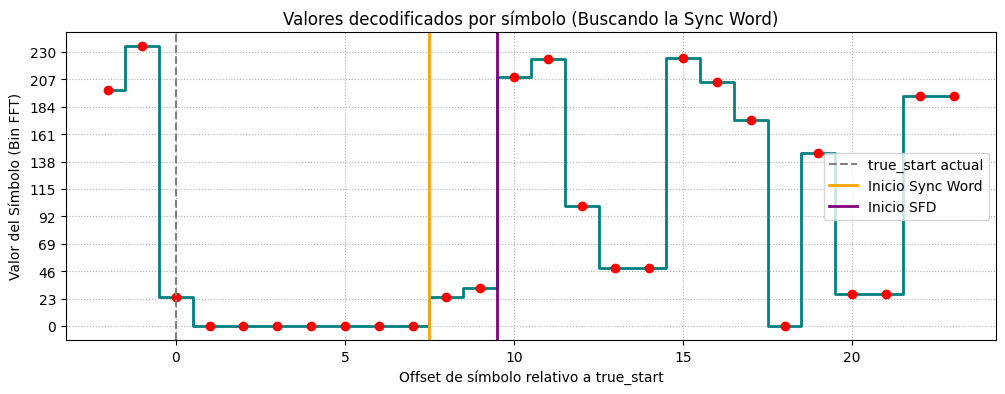

In [155]:
# ============================================================
# 5. ETAPA 3: DETECCIÓN DE LA SYNC WORD Y ALINEACIÓN DE FRAME
# ============================================================
# Demodulamos varios símbolos alrededor de nuestro true_start
# para encontrar el final del preámbulo y extraer la Sync Word.

if detected_window != -1:
    print("[*] Escaneando símbolos alrededor de true_start...")
    
    sym_offsets = range(-2, 24)
    decoded_vals = []
    peak_mags = []
    mags_down_list = []
    
    for k in sym_offsets:
        idx = true_start_idx + k * N_sym
        if idx < 0 or idx + N_sym > len(iq_synced):
            decoded_vals.append(-1)
            peak_mags.append(0)
            continue
            
        # Extraer símbolo y de-chirpear (asumimos up-chirp)
        sym_iq = iq_synced[idx : idx + N_sym]
        fft_val = np.abs(np.fft.fft(sym_iq * base_down))
        fft_val_down = np.abs(np.fft.fft(sym_iq * np.conj(base_down)))
        mag_down = np.max(fft_val_down[:N])
        
        # Buscar pico solo en la región válida (0 a N-1)
        peak_bin = np.argmax(fft_val[:N])
        
        decoded_vals.append(peak_bin)
        peak_mags.append(fft_val[peak_bin])
        mags_down_list.append(mag_down)
        
    # Imprimir tabla de resultados
    print(f"{'Offset':>8} | {'Bin (Up)':>10} | {'Mag (Up)':>10} | {'Mag (Down)':>10}")
    print("-" * 60)
    for k, val, mag, mag_d in zip(sym_offsets, decoded_vals, peak_mags, mags_down_list):
        marker = "<-- true_start" if k == 0 else ""
        print(f"{k:>8} | {val:>10} | {mag:>10.1f} | {mag_d:>10.1f} {marker}")
        
    # ===========================================================
    # Detección Algorítmica del Byte de Sync Word
    # ===========================================================
    preamble_end_idx = -1
    # Buscamos dónde se rompe la racha de ceros (preámbulo)
    for i in range(len(decoded_vals) - 3):
        # Tolerancia de +-1 bin por si hay ruido mínimo
        if all(abs(val) <= 1 or abs(val) >= N-1 for val in decoded_vals[i:i+4]):
            for j in range(i+4, len(decoded_vals)-1):
                if 1 < decoded_vals[j] < N-1:
                    preamble_end_idx = j
                    break
            if preamble_end_idx != -1:
                break
                
    if preamble_end_idx != -1 and preamble_end_idx + 1 < len(decoded_vals):
        sym1 = decoded_vals[preamble_end_idx]
        sym2 = decoded_vals[preamble_end_idx + 1]
        
        # Invertimos la lógica de Semtech: Símbolo = Nibble * 8
        nibble1 = round(sym1 / 8)
        nibble2 = round(sym2 / 8)
        sync_word = (nibble1 << 4) | nibble2
        
        print("\n[+] ¡Sync Word Aislada Exitosamente!")
        print(f"    Símbolos detectados: {sym1} y {sym2}")
        print(f"    Cálculo de Nibbles : {sym1}/8 = {nibble1} | {sym2}/8 = {nibble2}")
        print(f"    Valor de Registro  : 0x{sync_word:02X}")
        
        # Guardamos el índice donde arranca el SFD (justo después del Sync Word)
        sfd_start_offset = sym_offsets[preamble_end_idx + 2]
        print(f"    -> El SFD comienza en el offset {sfd_start_offset}")
    else:
        print("\n[-] No se pudo aislar la Sync Word automáticamente.")
        
    # Graficar la transición
    plt.figure(figsize=(12, 4))
    plt.step(sym_offsets, decoded_vals, where='mid', color='teal', linewidth=2)
    plt.plot(sym_offsets, decoded_vals, 'o', color='red')
    plt.axvline(0, color='gray', linestyle='--', label='true_start actual')
    if preamble_end_idx != -1:
        sw_offset = sym_offsets[preamble_end_idx]
        plt.axvline(sw_offset - 0.5, color='orange', linestyle='-', linewidth=2, label='Inicio Sync Word')
        plt.axvline(sw_offset + 1.5, color='purple', linestyle='-', linewidth=2, label='Inicio SFD')
    plt.title('Valores decodificados por símbolo (Buscando la Sync Word)')
    plt.xlabel('Offset de símbolo relativo a true_start')
    plt.ylabel('Valor del Símbolo (Bin FFT)')
    plt.yticks(range(0, max(decoded_vals)+10, max(1, max(decoded_vals)//10)))
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()
else:
    print("[-] Preámbulo no detectado.")


In [158]:
# ============================================================
# 6. DECODIFICACIÓN DEL PHY HEADER (Lógica de Semtech Adaptada)
# ============================================================
import numpy as np

decoded_L = 0
decoded_cr = 1
decoded_has_crc = 0

if detected_window != -1:
    header_start_idx = true_start_idx + int(12.25 * N_sym)
    
    bins_extraidos = []
    
    # 1. Extraer picos de los 8 símbolos
    for i in range(8):
        idx = header_start_idx + i * N_sym
        sym_iq = iq_synced[idx : idx + N_sym]
        
        # De-Chirp
        señal_dechirped = sym_iq * base_down
        
        # FFT y fold (porque Os=4, la FFT es de 1024, la doblamos a 256)
        Z_mag_sq = np.abs(np.fft.fft(señal_dechirped))**2
        folded = Z_mag_sq[:256] + Z_mag_sq[256:512] + Z_mag_sq[512:768] + Z_mag_sq[768:1024]
        
        peak_idx = int(np.argmax(folded))
        
        # ==============================================================
        # EL DETALLE CRÍTICO DEL HEADER (Desfase de 1 bin + Reduced Rate)
        # ==============================================================
        simbolo_crudo = (peak_idx - 1) % 256
        simbolo_header = simbolo_crudo // 4
        bins_extraidos.append(simbolo_header)
        
    print(f"[*] Bins del Header (Reduced): {bins_extraidos}")
    
    # 2. Gray Demapping
    demapped_symbols = [sym ^ (sym >> 1) for sym in bins_extraidos]
    
    # 3. Extracción de bits (sf_app = SF - 2 = 6)
    sf_app = 6
    inter_bin = []
    for sym in demapped_symbols:
        bits = [(sym >> i) & 1 for i in range(sf_app - 1, -1, -1)]
        inter_bin.append(bits)
        
    # 4. Desentrelazado Diagonal
    cw_len = 8
    deinter_bin = [[0] * cw_len for _ in range(sf_app)]
    for i in range(cw_len):
        for j in range(sf_app):
            idx = (i - j - 1) % sf_app
            deinter_bin[idx][i] = inter_bin[i][j]
            
    # 5. Decodificación Hamming(8,4)
    nibbles = []
    for cw in deinter_bin:
        s0 = cw[0] ^ cw[1] ^ cw[2] ^ cw[4]
        s1 = cw[1] ^ cw[2] ^ cw[3] ^ cw[5]
        s2 = cw[0] ^ cw[1] ^ cw[3] ^ cw[6]
        syndrome = s0 + (s1 << 1) + (s2 << 2)
        d0, d1, d2, d3 = cw[0], cw[1], cw[2], cw[3]
        
        if syndrome == 5: d0 ^= 1
        elif syndrome == 7: d1 ^= 1
        elif syndrome == 3: d2 ^= 1
        elif syndrome == 6: d3 ^= 1
            
        nibble = (d3 << 3) | (d2 << 2) | (d1 << 1) | d0
        nibbles.append(nibble)
        
    # 6. Parseo del Header
    n0, n1, n2, n3, n4 = nibbles[0:5]
    payload_len = (n0 << 4) + n1
    has_crc = bool(n2 & 1)
    cr = n2 >> 1
    header_chk = ((n3 & 1) << 4) + n4
    
    c4 = ((n0 & 0b1000) >> 3) ^ ((n0 & 0b0100) >> 2) ^ ((n0 & 0b0010) >> 1) ^ (n0 & 0b0001)
    c3 = ((n0 & 0b1000) >> 3) ^ ((n1 & 0b1000) >> 3) ^ ((n1 & 0b0100) >> 2) ^ ((n1 & 0b0010) >> 1) ^ (n2 & 0b0001)
    c2 = ((n0 & 0b0100) >> 2) ^ ((n1 & 0b1000) >> 3) ^ (n1 & 0b0001) ^ ((n2 & 0b1000) >> 3) ^ ((n2 & 0b0010) >> 1)
    c1 = ((n0 & 0b0010) >> 1) ^ ((n1 & 0b0100) >> 2) ^ (n1 & 0b0001) ^ ((n2 & 0b0100) >> 2) ^ ((n2 & 0b0010) >> 1) ^ (n2 & 0b0001)
    c0 = (n0 & 0b0001) ^ ((n1 & 0b0010) >> 1) ^ ((n2 & 0b1000) >> 3) ^ ((n2 & 0b0100) >> 2) ^ ((n2 & 0b0010) >> 1) ^ (n2 & 0b0001)
    
    expected_chk = (c4 << 4) + (c3 << 3) + (c2 << 2) + (c1 << 1) + c0
    is_valid = (header_chk == expected_chk) and (payload_len > 0)
    
    decoded_L = payload_len
    decoded_cr = cr
    decoded_has_crc = has_crc
    
    print("\n" + "=" * 50)
    print(" RESULTADO CABECERA (ESTÁNDAR LORA)")
    print("=" * 50)
    print(f" [+] Payload Length (L) : {decoded_L} bytes")
    print(f" [+] Coding Rate (CR)   : 4/{decoded_cr+4}")
    print(f" [+] MAC CRC Presente   : {'Sí' if decoded_has_crc else 'No'}")
    print(f" [+] Checksum OK        : {'SÍ ✅' if is_valid else 'NO ⚠️'}")
    print(f"     Calculado={expected_chk}, Recibido={header_chk}")
    print("=" * 50)



[*] Bins del Header (Reduced): [41, 28, 8, 3, 59, 15, 14, 52]

 RESULTADO CABECERA (ESTÁNDAR LORA)
 [+] Payload Length (L) : 16 bytes
 [+] Coding Rate (CR)   : 4/5
 [+] MAC CRC Presente   : Sí
 [+] Checksum OK        : SÍ ✅
     Calculado=29, Recibido=29


In [161]:
# ============================================================
# 7. DECODIFICACIÓN DEL PAYLOAD
# ============================================================
import numpy as np
import math

if detected_window != -1 and decoded_L > 0:
    payload_start_idx = true_start_idx + int(20.25 * N_sym)
    
    total_nibbles = decoded_L * 2 + (4 if decoded_has_crc else 0)
    cw_len = decoded_cr + 4
    sf_app = 8  # payload sin LDRO
    blocks_needed = math.ceil(total_nibbles / sf_app)
    syms_needed = blocks_needed * cw_len
    
    print(f"[*] Header dice: L={decoded_L}, CR=4/{decoded_cr+4}, CRC={'Sí' if decoded_has_crc else 'No'}")
    print(f"[*] Necesito {total_nibbles} nibbles = {blocks_needed} bloques × {cw_len} símbolos = {syms_needed} símbolos")
    
    n_syms = min(syms_needed, int((len(iq_synced) - payload_start_idx) / N_sym))
    
    raw_bins = []
    for i in range(n_syms):
        idx = payload_start_idx + i * N_sym
        sym_iq = iq_synced[idx : idx + N_sym]
        dechirped = sym_iq * base_down
        Z_mag_sq = np.abs(np.fft.fft(dechirped))**2
        folded = Z_mag_sq[:256] + Z_mag_sq[256:512] + Z_mag_sq[512:768] + Z_mag_sq[768:1024]
        raw_bins.append(int(np.argmax(folded)))
        
    # Offset y Gray decode
    adjusted = [(b - 1) % 256 for b in raw_bins]
    grayed = [s ^ (s >> 1) for s in adjusted]
    
    inter_bin = []
    for sym in grayed:
        # LSB-first
        bits = [(sym >> i) & 1 for i in range(sf_app)]
        inter_bin.append(bits)
        
    nibbles = []
    for b_start in range(0, len(inter_bin), cw_len):
        block = inter_bin[b_start : b_start + cw_len]
        if len(block) < cw_len:
            break
        deinter = [[0] * cw_len for _ in range(sf_app)]
        for i in range(cw_len):
            for j in range(sf_app):
                idx2 = (i - j - 1) % sf_app
                deinter[idx2][i] = block[i][j]
                
        for cw in deinter:
            d0, d1, d2, d3 = cw[0], cw[1], cw[2], cw[3]
            # Si CR=4/5, solo hay 1 bit de paridad (cw[4]), no se puede corregir errores.
            if decoded_cr >= 3: # 4/7 o 4/8
                s0 = cw[0] ^ cw[1] ^ cw[2] ^ cw[4]
                s1 = cw[1] ^ cw[2] ^ cw[3] ^ cw[5]
                s2 = cw[0] ^ cw[1] ^ cw[3] ^ cw[6]
                syndrome = s0 + (s1 << 1) + (s2 << 2)
                if syndrome == 5: d0 ^= 1
                elif syndrome == 7: d1 ^= 1
                elif syndrome == 3: d2 ^= 1
                elif syndrome == 6: d3 ^= 1
            
            nibbles.append((d3 << 3) | (d2 << 2) | (d1 << 1) | d0)
            
    bytes_wh = []
    whitening_seq = [
        0xFF, 0xFE, 0xFC, 0xF8, 0xF0, 0xE1, 0xC2, 0x85, 0x0B, 0x17, 0x2F, 0x5E, 0xBC, 0x78, 0xF1, 0xE3,
        0xC6, 0x8D, 0x1A, 0x34, 0x68, 0xD0, 0xA0, 0x40, 0x80, 0x01, 0x02, 0x04, 0x08, 0x11, 0x23, 0x47,
        0x8E, 0x1C, 0x38, 0x71, 0xE2, 0xC4, 0x89, 0x12, 0x25, 0x4B, 0x97, 0x2E, 0x5C, 0xB8, 0x70, 0xE0,
    ]
    for i in range(min(decoded_L, len(nibbles)//2)):
        lo = nibbles[2*i]
        hi = nibbles[2*i + 1]
        if i < len(whitening_seq):
            sv = whitening_seq[i]
            lo ^= (sv & 0x0F)
            hi ^= (sv >> 4) & 0x0F
        bytes_wh.append((hi << 4) | lo)
        
    hex_wh = ' '.join(f'{b:02X}' for b in bytes_wh)
    ascii_wh = ''.join(chr(b) if 32 <= b < 127 else '.' for b in bytes_wh)
    
    print(f"\n{'='*50}")
    print(" MENSAJE DECODIFICADO (ASCII)")
    print(f"{'='*50}")
    print(f" [+] Texto: '{ascii_wh}'")
    print(f" [+] Hex  : {hex_wh}")
    print(f"{'='*50}")
else:
    print("[-] Header inválido o L=0.")



[*] Header dice: L=16, CR=4/5, CRC=Sí
[*] Necesito 36 nibbles = 5 bloques × 5 símbolos = 25 símbolos

[1] Bins crudos (primeros 30): [91, 1, 1, 204, 64, 142, 88, 173, 212, 160, 137, 219, 67, 31, 77, 247, 112, 66, 85, 217, 208, 82, 86, 79, 140, 139, 245, 47, 65, 215]

 Variante: CON -1
  Nibbles crudos (primeros 20): [9, 1, 9, 0, 9, 9, 9, 0, 13, 5, 8, 7, 10, 6, 15, 15, 6, 2, 7, 15]
  Bytes SIN whitening: 19 09 99 09 5D 78 6A FF 26 F7 20 D3 8D 15 AA F8
  ASCII SIN whitening: '....]xj.&. .....'
  Bytes CON whitening: E6 F7 65 F1 AD 99 A8 7A 2D E0 0F 8D 31 6D 5B 1B
  ASCII CON whitening: '..e....z-...1m[.'

 Variante: SIN offset
  Nibbles crudos (primeros 20): [8, 3, 13, 0, 9, 1, 9, 0, 13, 4, 12, 7, 8, 14, 15, 15, 7, 0, 3, 7]
  Bytes SIN whitening: 38 0D 19 09 4D 7C E8 FF 07 73 20 D3 8C D5 8A F8
  ASCII SIN whitening: '8...M|...s .....'
  Bytes CON whitening: C7 F3 E5 F1 BD 9D 2A 7A 0C 64 0F 8D 30 AD 7B 1B
  ASCII CON whitening: '......*z.d..0.{.'

 ¿Qué mensaje transmitiste? Pasame el tex